<a href="https://colab.research.google.com/github/thesamokoosi/CodeAlpha_Sales-Prediction/blob/main/CodeAlpha_Sales_Predictiom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Task 4: Sales Prediction

# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 14,
                     "axes.labelsize": 12})

# LOAD DATA

df = pd.read_csv("Advertising.csv") # <-- update filename if needed
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic statistics:")
print(df.describe().round(2))

# DATA CLEANING
df.columns = df.columns.str.strip()
df.dropna(inplace=True)

# Drop unnamed index column if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

print("\nCleaned shape:", df.shape)


Shape: (200, 5)

First 5 rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Column names: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Missing values:
 Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Basic statistics:
       Unnamed: 0      TV   Radio  Newspaper   Sales
count      200.00  200.00  200.00     200.00  200.00
mean       100.50  147.04   23.26      30.55   14.02
std         57.88   85.85   14.85      21.78    5.22
min          1.00    0.70    0.00       0.30    1.60
25%         50.75   74.38    9.98      12.75   10.38
50%        100.50  149.75   22.90      25.75   12.90
75%        150.25  218.82   36.52      45.10   17.40
max        200.00  296.40   49.60     114.00   27.00

Cleaned shape: (20

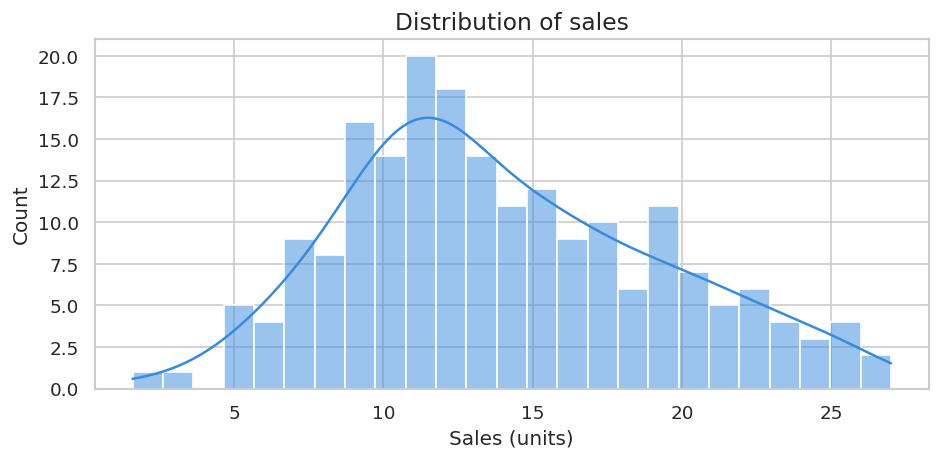

Saved: plot1_sales_distribution.png


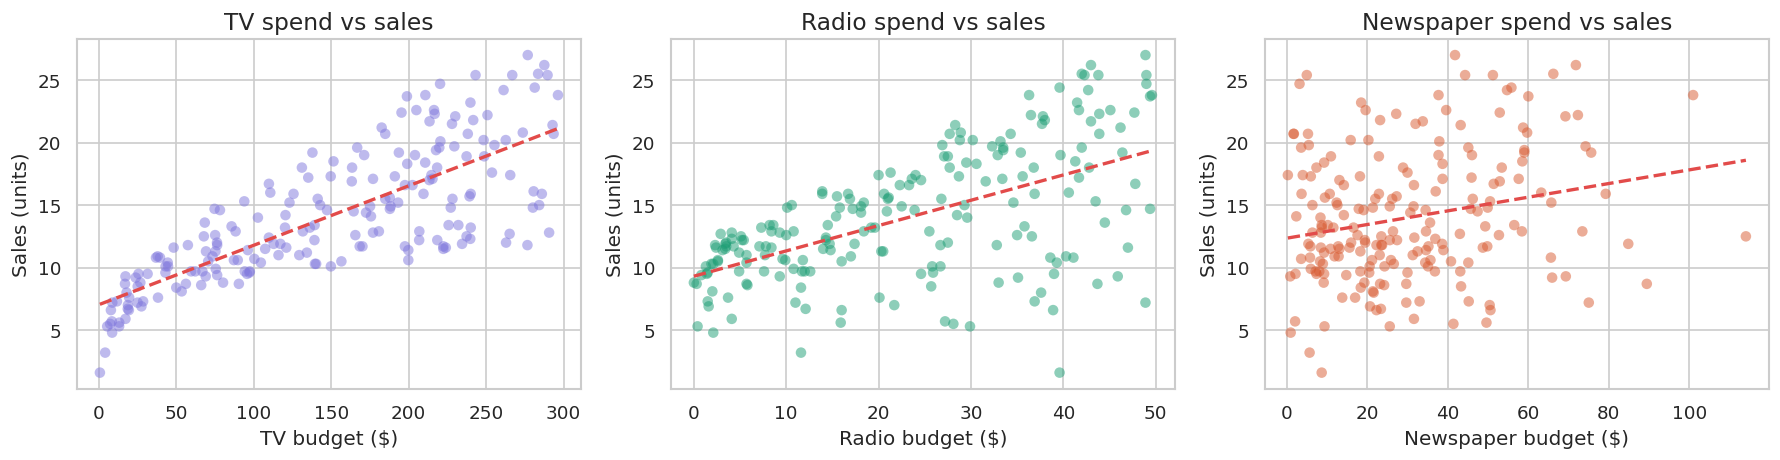

Saved: plot2_spend_vs_sales.png


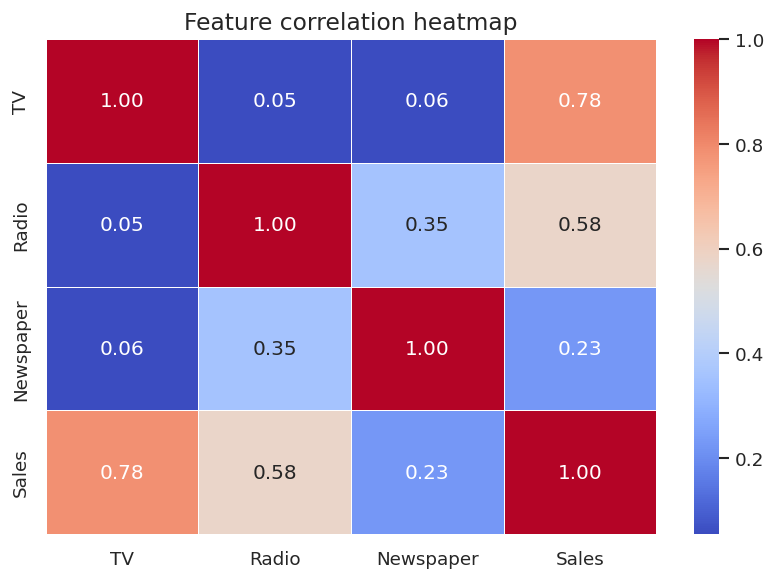

Saved: plot3_correlation.png


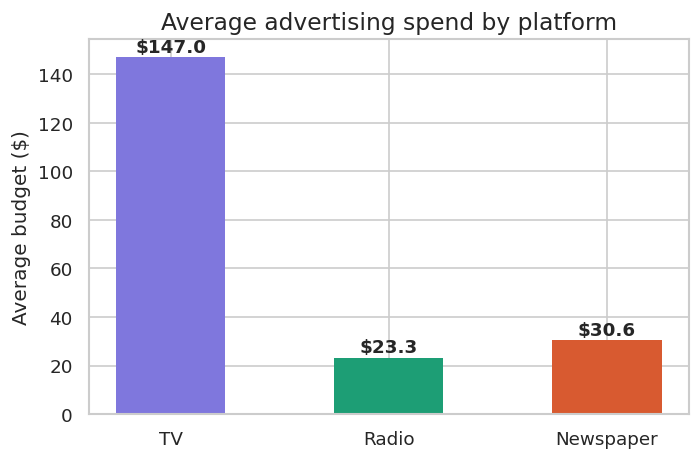

Saved: plot4_avg_spend.png


In [3]:
# EXPLORATORY DATA ANALYSIS
# Distribution of Sales
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["Sales"], bins=25, kde=True, color="#378ADD", ax=ax)
ax.set_title("Distribution of sales")
ax.set_xlabel("Sales (units)")
plt.tight_layout()
plt.savefig("plot1_sales_distribution.png", dpi=150)
plt.show()
print("Saved: plot1_sales_distribution.png")

# Advertising spend vs Sales (scatter for each platform)
platforms = ["TV", "Radio", "Newspaper"]
colors = ["#7F77DD", "#1D9E75", "#D85A30"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, platform, color in zip(axes, platforms, colors):
    ax.scatter(df[platform], df["Sales"],
               alpha=0.5, color=color, edgecolors="none", s=40)
    m, b = np.polyfit(df[platform], df["Sales"], 1)
    x_line = np.linspace(df[platform].min(), df[platform].max(), 100)
    ax.plot(x_line, m * x_line + b, color="#E24B4A",
            linewidth=2, linestyle="--")
    ax.set_title(f"{platform} spend vs sales")
    ax.set_xlabel(f"{platform} budget ($)")
    ax.set_ylabel("Sales (units)")
plt.tight_layout()
plt.savefig("plot2_spend_vs_sales.png", dpi=150)
plt.show()
print("Saved: plot2_spend_vs_sales.png")

# Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax)
ax.set_title("Feature correlation heatmap")
plt.tight_layout()
plt.savefig("plot3_correlation.png", dpi=150)
plt.show()
print("Saved: plot3_correlation.png")

# Advertising budget breakdown (average spend per platform)
avg_spend = df[platforms].mean()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(platforms, avg_spend.values,
              color=colors, edgecolor="none", width=0.5)
for bar, val in zip(bars, avg_spend.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5, f"${val:.1f}",
            ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Average advertising spend by platform")
ax.set_ylabel("Average budget ($)")
plt.tight_layout()
plt.savefig("plot4_avg_spend.png", dpi=150)
plt.show()
print("Saved: plot4_avg_spend.png")



In [4]:
# ── 5. PREPARE FEATURES & TARGET ─────────────────────────────
X = df[platforms]
y = df["Sales"]

print("\nFeatures:", X.columns.tolist())
print("Target : Sales")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# ── 6. TRAIN MODELS ──────────────────────────────────────────
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
print("\n── Model Evaluation ──")
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    cv = cross_val_score(model, scaler.transform(X), y, cv=5, scoring="r2")
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2,
                     "CV_mean": cv.mean(), "preds": preds}
    print(f"\n {name}")
    print(f" MAE : {mae:.4f}")
    print(f" RMSE : {rmse:.4f}")
    print(f" R² : {r2:.4f}")
    print(f" CV R² (5x) : {cv.mean():.4f} ± {cv.std():.4f}")



Features: ['TV', 'Radio', 'Newspaper']
Target : Sales

── Model Evaluation ──

 Linear Regression
 MAE : 1.4608
 RMSE : 1.7816
 R² : 0.8994
 CV R² (5x) : 0.8871 ± 0.0403

 Random Forest
 MAE : 0.6207
 RMSE : 0.7688
 R² : 0.9813
 CV R² (5x) : 0.9755 ± 0.0094

 Gradient Boosting
 MAE : 0.6181
 RMSE : 0.7295
 R² : 0.9831
 CV R² (5x) : 0.9777 ± 0.0093



Best model: Gradient Boosting (R² = 0.9831)


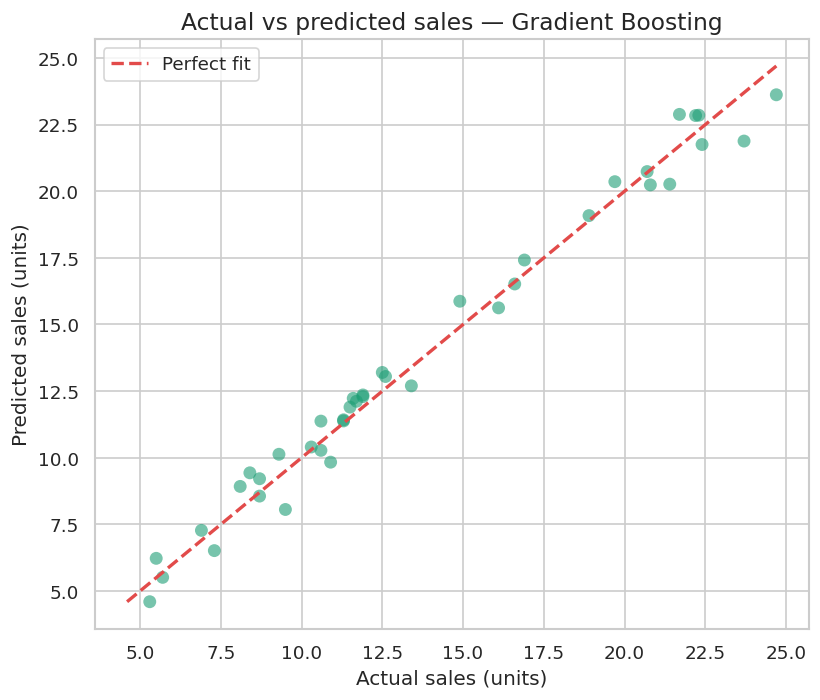

Saved: plot5_actual_vs_predicted.png


In [5]:
# ── 7. BEST MODEL — ACTUAL vs PREDICTED ──────────────────────
best_name = max(results, key=lambda k: results[k]["R2"])
best_preds = results[best_name]["preds"]
print(f"\nBest model: {best_name} (R² = {results[best_name]['R2']:.4f})")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, best_preds, alpha=0.6,
           color="#1D9E75", edgecolors="none", s=60)
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color="#E24B4A", linewidth=2, linestyle="--", label="Perfect fit")
ax.set_title(f"Actual vs predicted sales — {best_name}")
ax.set_xlabel("Actual sales (units)")
ax.set_ylabel("Predicted sales (units)")
ax.legend()
plt.tight_layout()
plt.savefig("plot5_actual_vs_predicted.png", dpi=150)
plt.show()
print("Saved: plot5_actual_vs_predicted.png")



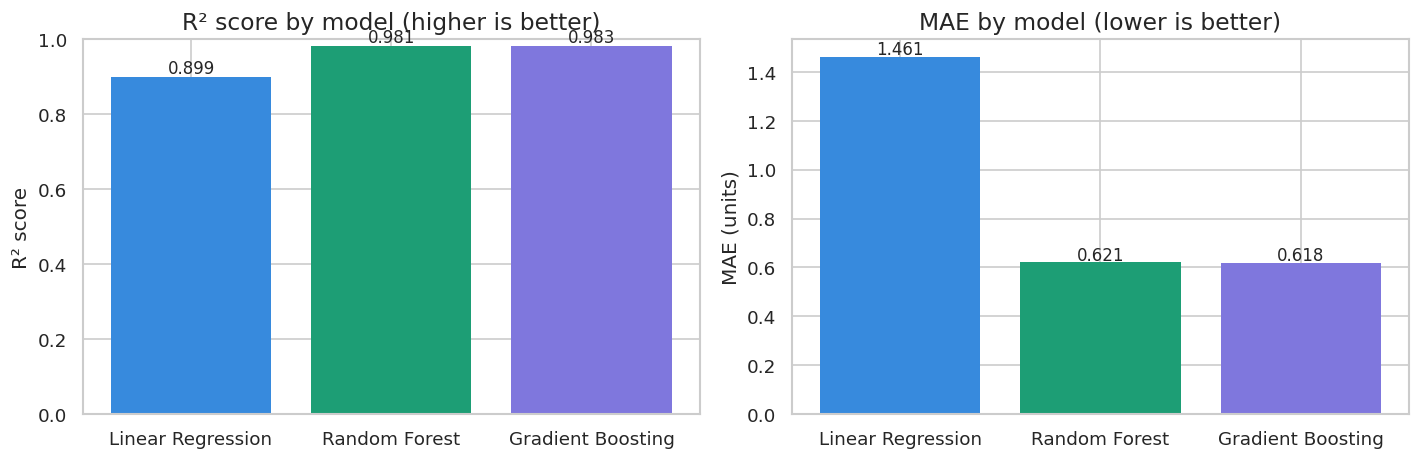

Saved: plot6_model_comparison.png


In [6]:
# ── 8. MODEL COMPARISON CHART ────────────────────────────────
model_names = list(results.keys())
r2_scores = [results[m]["R2"] for m in model_names]
mae_scores = [results[m]["MAE"] for m in model_names]
bar_colors = ["#378ADD", "#1D9E75", "#7F77DD"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(model_names, r2_scores, color=bar_colors, edgecolor="none")
axes[0].set_title("R² score by model (higher is better)")
axes[0].set_ylabel("R² score")
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

axes[1].bar(model_names, mae_scores, color=bar_colors, edgecolor="none")
axes[1].set_title("MAE by model (lower is better)")
axes[1].set_ylabel("MAE (units)")
for i, v in enumerate(mae_scores):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("plot6_model_comparison.png", dpi=150)
plt.show()
print("Saved: plot6_model_comparison.png")


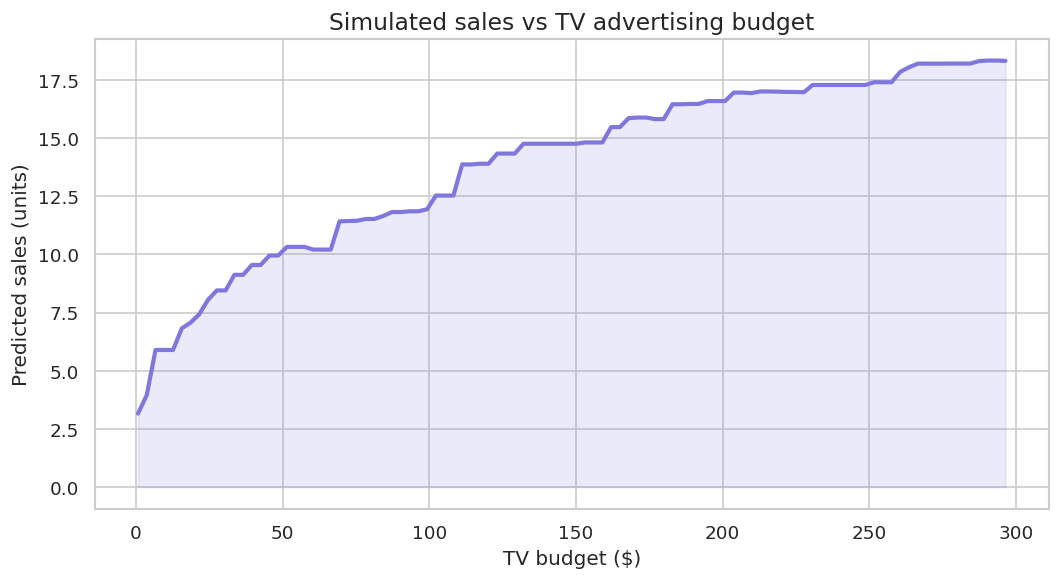

Saved: plot7_tv_impact_simulation.png


In [7]:
# ── 9. ADVERTISING IMPACT SIMULATION ─────────────────────────
# Show how increasing TV budget affects predicted sales
best_model = models[best_name]
tv_range = np.linspace(df["TV"].min(), df["TV"].max(), 100)
radio_avg = df["Radio"].mean()
news_avg = df["Newspaper"].mean()
sim_data = pd.DataFrame({
    "TV": tv_range,
    "Radio": [radio_avg] * 100,
    "Newspaper": [news_avg] * 100
})
sim_preds = best_model.predict(scaler.transform(sim_data))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tv_range, sim_preds, color="#7F77DD", linewidth=2.5)
ax.fill_between(tv_range, sim_preds, alpha=0.15, color="#7F77DD")
ax.set_title("Simulated sales vs TV advertising budget")
ax.set_xlabel("TV budget ($)")
ax.set_ylabel("Predicted sales (units)")
plt.tight_layout()
plt.savefig("plot7_tv_impact_simulation.png", dpi=150)
plt.show()
print("Saved: plot7_tv_impact_simulation.png")


In [8]:
# ── 10. KEY INSIGHTS ─────────────────────────────────────────
tv_corr = df["TV"].corr(df["Sales"])
radio_corr = df["Radio"].corr(df["Sales"])
news_corr = df["Newspaper"].corr(df["Sales"])

print("\n" + "="*55)
print(" KEY INSIGHTS")
print("="*55)
print(f" 1. Best model : {best_name}")
print(f" 2. Best R² score : {results[best_name]['R2']:.4f}")
print(f" 3. Best MAE : {results[best_name]['MAE']:.4f} units")
print(f" 4. TV correlation : {tv_corr:.4f} ← strongest predictor")
print(f" 5. Radio correlation : {radio_corr:.4f}")
print(f" 6. Newspaper corr. : {news_corr:.4f} ← weakest predictor")
print(f" 7. Avg sales : {y.mean():.2f} units")
print(f" 8. Max sales : {y.max():.2f} units")
print(f" 9. Business insight : TV ads drive the most sales impact.")
print(f" Reallocating budget from Newspaper to TV/Radio")
print(f" is likely to improve sales outcomes.")
print("="*55)
print("\nAll plots saved. Analysis complete!")


 KEY INSIGHTS
 1. Best model : Gradient Boosting
 2. Best R² score : 0.9831
 3. Best MAE : 0.6181 units
 4. TV correlation : 0.7822 ← strongest predictor
 5. Radio correlation : 0.5762
 6. Newspaper corr. : 0.2283 ← weakest predictor
 7. Avg sales : 14.02 units
 8. Max sales : 27.00 units
 9. Business insight : TV ads drive the most sales impact.
 Reallocating budget from Newspaper to TV/Radio
 is likely to improve sales outcomes.

All plots saved. Analysis complete!


In [10]:
# DOWNLOAD ALL PLOTS
from google.colab import files
plots = [
 "plot1_sales_distribution.png",
 "plot2_spend_vs_sales.png",
 "plot3_correlation.png",
 "plot4_avg_spend.png",
 "plot5_actual_vs_predicted.png",
 "plot6_model_comparison.png",
 "plot7_tv_impact_simulation.png",
 ]
for plot in plots:
    files.download(plot)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>